# Chapter 3 — Autoencoder を自作する

MNIST を使い、全結合AE → Conv AE → 潜在空間の可視化 → VAE の順に段階的に実装する

## 0. セットアップ（import / device）

In [2]:
from datasets import load_dataset

## 1. データセット（MNIST）

データは chapter3/data/ に配置

In [3]:
mnist = load_dataset("ylecun/mnist")
mnist

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
mnist["train"]["image"][1]

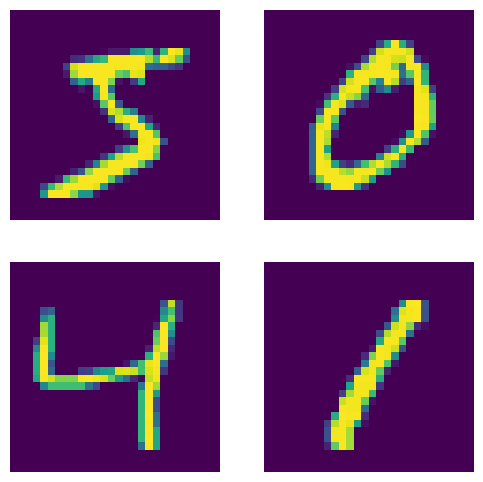

In [5]:
from genaibook.core import show_images
show_images(mnist["train"]["image"][:4])

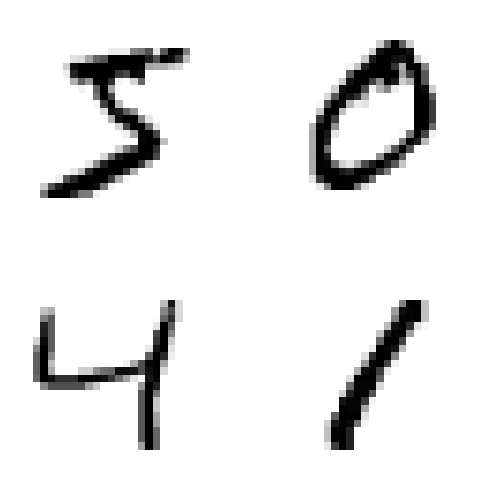

In [6]:
import matplotlib as mpl

mpl.rcParams["image.cmap"] = "gray_r"
show_images(mnist["train"]["image"][:4])

In [7]:
from torchvision import transforms
def mnist_to_tensor(samples):
    t = transforms.ToTensor()
    samples["image"] = [t(image) for image in samples["image"]]
    return samples

In [8]:
mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

In [9]:
x = mnist["train"]["image"][0]
x.min(), x.max()

(tensor(0.), tensor(1.))

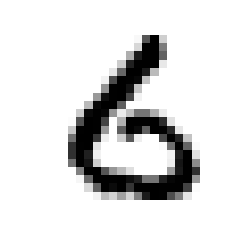

In [10]:
show_images(mnist["train"]["image"][0])

In [11]:
from torch.utils.data import DataLoader
bs = 64
train_data_loader = DataLoader(mnist["train"]["image"], batch_size=bs)

In [12]:
import torch
from torch import nn

def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
    )


class Encoder(nn.Module):
    def __init__(self, in_channels, latent_dim=16):
        super().__init__()
        self.conv1 = conv_block(in_channels, 128) # (128, 14, 14)
        self.conv2 = conv_block(128, 256)  # (256, 7, 7)
        self.conv3 = conv_block(256, 512)  # (512, 3, 3)
        self.conv4 = conv_block(512, 1024)  # (1024, 1, 1)
        self.linear = nn.Linear(1024, latent_dim) #(bs, latent_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.linear(x.flatten(start_dim=1))
        return x

In [13]:
mnist["train"]["image"][0].shape

torch.Size([1, 28, 28])

In [14]:
in_channels = 1
x = mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()
encoded = encoder(x)
encoded.shape

torch.Size([1, 16])

In [15]:
encoded

tensor([[ 0.0212,  0.0211, -0.0223, -0.0049, -0.0103, -0.0062, -0.0273, -0.0008,
         -0.0339, -0.0145,  0.0059, -0.0255,  0.0032, -0.0272,  0.0205, -0.0125]],
       grad_fn=<AddmmBackward0>)

In [16]:
batch = next(iter(train_data_loader))
encoded = Encoder(in_channels)(batch)
batch.shape, encoded.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64, 16]))

In [17]:
def conv_transpose_block(in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=0, with_act=True):
    modules = [
        nn.ConvTranspose2d(
                    in_channels, out_channels, kernel_size,
                    stride=stride, padding=padding, output_padding=output_padding,
                )
    ]
    if with_act: # 後々のことを考えて制御できるようにしておく
        modules.append(nn.BatchNorm2d(out_channels))
        modules.append(nn.ReLU())
    return nn.Sequential(*modules)


class Decoder(nn.Module):
    def __init__(self, out_channels, latent_dim=16):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 1024 * 4 * 4)
        self.t_conv1 = conv_transpose_block(1024, 512)
        self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
        self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1)

    # forward 内で形状が変化している点に注意
    def forward(self, x):
        bs = x.shape[0]
        x = self.linear(x)  # (bs, 1024*4*4)
        x = x.reshape((bs, 1024, 4, 4))  # (bs, 1024, 4, 4)
        x = self.t_conv1(x)  # (bs, 512, 7, 7)
        x = self.t_conv2(x)  # (bs, 256, 14, 14)
        x = self.t_conv3(x)  # (bs, 1, 28, 28)
        return x

In [18]:
decoded_batch = Decoder(x.shape[0])(encoded)
decoded_batch.shape

torch.Size([64, 1, 28, 28])

In [19]:
class AutoEncoder(nn.Module):
    def __init__(self, in_channels, latent_dim=16):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        self.decoder = Decoder(in_channels, latent_dim)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        return self.decode(self.encode(x))


model = AutoEncoder(1)

In [20]:
import torchsummary

torchsummary.summary(model, input_size=(1, 28, 28), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 14, 14]           2,176
       BatchNorm2d-2          [-1, 128, 14, 14]             256
              ReLU-3          [-1, 128, 14, 14]               0
            Conv2d-4            [-1, 256, 7, 7]         524,544
       BatchNorm2d-5            [-1, 256, 7, 7]             512
              ReLU-6            [-1, 256, 7, 7]               0
            Conv2d-7            [-1, 512, 3, 3]       2,097,664
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
              ReLU-9            [-1, 512, 3, 3]               0
           Conv2d-10           [-1, 1024, 1, 1]       8,389,632
      BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
             ReLU-12           [-1, 1024, 1, 1]               0
           Linear-13                   [-1, 16]          16,400
          Encoder-14                   

## 2. 全結合オートエンコーダ

## 3. 学習ループ

In [21]:
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
from tqdm.notebook import tqdm, trange

from genaibook.core import get_device

num_epochs = 10
lr = 1e-4

device = get_device()
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)

losses = []  # 描画用に損失を保存するリスト
for _ in (progress := trange(num_epochs, desc="Training")):
    for _, batch in (
        inner := tqdm(enumerate(train_data_loader), total=len(train_data_loader))
    ):
        batch = batch.to(device)

        # モデルに渡して再構成画像を取得する
        preds = model(batch)

        # 予測結果と元画像を比較する
        loss = F.mse_loss(preds, batch)

        # 損失を表示し、描画用に保存する
        inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
        losses.append(loss.item())

        # 損失に基づいてモデルのパラメーターを更新する
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

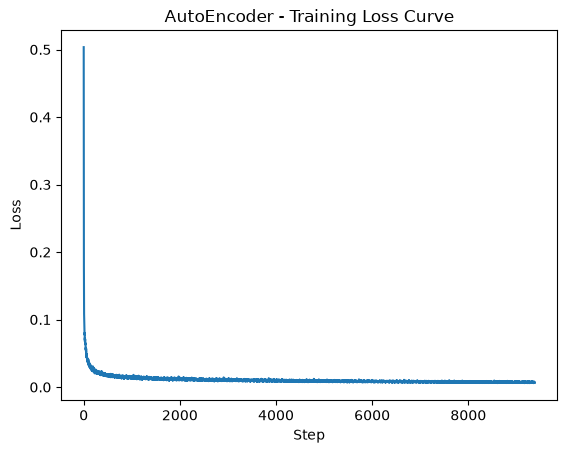

In [22]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AutoEncoder - Training Loss Curve")
plt.show()

## 4. 再構成結果の可視化

In [23]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["train"]["image"], batch_size=eval_bs)
model.eval()
with torch.inference_mode():
    eval_batch = next(iter(eval_dataloader))
    predicted = model(eval_batch.to(device)).cpu()

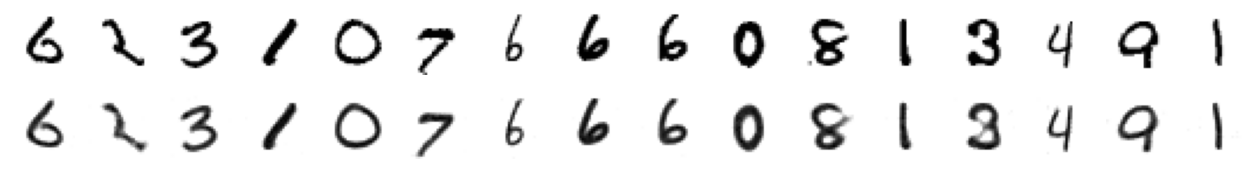

In [24]:
batch_vs_preds = torch.cat((eval_batch, predicted))
show_images(batch_vs_preds, imsize=1, nrows=2)

## 5. Conv オートエンコーダ

## 6. 潜在空間の可視化

In [ ]:
# 潜在ベクトルを 2 次元に絞ったモデルをあらためて訓練する
ae_num_epochs = 10
ae_lr = 1e-4

ae_model = AutoEncoder(in_channels, latent_dim=2).to(device)
ae_optimizer = torch.optim.AdamW(ae_model.parameters(), lr=ae_lr, eps=1e-5)

ae_losses = []
for _ in (progress := trange(ae_num_epochs, desc="Training (latent_dim=2)")):
    for _, batch in (
        inner := tqdm(enumerate(train_data_loader), total=len(train_data_loader))
    ):
        batch = batch.to(device)
        preds = ae_model(batch)
        loss = F.mse_loss(preds, batch)
        inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
        ae_losses.append(loss.item())
        loss.backward()
        ae_optimizer.step()
        ae_optimizer.zero_grad()
        progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{ae_lr:.0e}")

In [ ]:
images_labels_dataloader = DataLoader(mnist["test"], batch_size=512)

In [ ]:
import pandas as pd

df = pd.DataFrame(
    {
        "x": [],
        "y": [],
        "label": [],
    }
)
for batch in tqdm(
    iter(images_labels_dataloader), total=len(images_labels_dataloader)
):
    encoded = ae_model.encode(batch["image"].to(device)).cpu()
    new_items = {
        "x": [t.item() for t in encoded[:, 0]],
        "y": [t.item() for t in encoded[:, 1]],
        "label": batch["label"],
    }
    df = pd.concat([df, pd.DataFrame(new_items)], ignore_index=True)

In [ ]:
plt.figure(figsize=(10, 8))
for label in range(10):
    points = df[df["label"] == label]
    plt.scatter(points["x"], points["y"], label=label, marker=".")

plt.legend();

In [ ]:
N = 16  # 16個の点を生成する
z = torch.rand((N, 2)) * 8 - 4

In [ ]:
plt.figure(figsize=(10, 8))
for label in range(10):
    points = df[df["label"] == label]
    plt.scatter(points["x"], points["y"], label=label, marker=".")

plt.scatter(z[:, 0], z[:, 1], label="z", marker="s", color="black")
plt.legend();

In [ ]:
ae_decoded = ae_model.decode(z.to(device))
show_images(ae_decoded.cpu(), imsize=1, nrows=1, suptitle="AutoEncoder")

## 7. VAE（再パラメータ化トリック + KL ダイバージェンス）